In [ ]:
# =======================================================
# Ejemplo completo: Predicción de Probabilidad de Reclamo en Seguros de Auto con Naive Bayes
# Problema de CLASIFICACIÓN BINARIA: predecir 'claim' (1 = reclamo, 0 = no reclamo)
# Dataset sintético profesional con 16 variables realistas para seguros de auto
# Incluye: EDA, entrenamiento, métricas, predicciones, análisis de riesgo (bajo/medio/alto con probabilidades),
# y análisis de sensibilidad con SHAP (KernelExplainer para Naive Bayes)
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn matplotlib seaborn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB  # Naive Bayes para variables mixtas (asumimos Gaussian)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
import shap
from shap import KernelExplainer
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos 10,000 conductores con 16 variables realistas para seguros de auto
# Target: 'claim' (1 = reclamo en el año, 0 = no) generado con lógica probabilística
np.random.seed(42)
n_samples = 10000

data = {
    # Demográficas
    'age': np.random.randint(18, 80, n_samples),  # Edad del conductor
    'gender': np.random.choice(['Male', 'Female'], n_samples, p=[0.55, 0.45]),  # Género
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced'], n_samples),  # Estado civil
    'education_level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),  # Nivel educativo
    'income_level': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.3, 0.5, 0.2]),  # Nivel ingresos
    'residence_type': np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples),  # Tipo de residencia
    
    # Vehículo y conducción
    'vehicle_age': np.random.randint(0, 20, n_samples),  # Edad del vehículo
    'vehicle_type': np.random.choice(['Sedan', 'SUV', 'Truck', 'Sports Car'], n_samples),  # Tipo de vehículo
    'annual_miles_driven': np.random.normal(12000, 5000, n_samples).clip(1000, 30000).astype(int),  # Millas anuales
    'driving_experience_years': np.random.randint(0, 60, n_samples),  # Años de experiencia
    'traffic_violations': np.random.randint(0, 5, n_samples),  # Violaciones de tráfico en los últimos 5 años
    'previous_accidents': np.random.randint(0, 3, n_samples),  # Accidentes previos
    
    # Médicas/Comportamiento
    'alcohol_consumption': np.random.choice(['None', 'Low', 'Moderate', 'High'], n_samples),  # Consumo alcohol
    'health_condition': np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], n_samples),  # Condición de salud
    'credit_score': np.random.normal(700, 100, n_samples).clip(300, 850).astype(int),  # Puntaje crediticio
    'driving_habits': np.random.choice(['Safe', 'Average', 'Risky'], n_samples, p=[0.5, 0.3, 0.2])  # Hábitos de conducción
}

df = pd.DataFrame(data)

# Generar 'claim' con lógica probabilística realista (mayor riesgo = mayor prob reclamo)
claim_prob = (
    0.05 +  # Base 5%
    0.20 * (df['age'] < 25) + 0.10 * (df['age'] > 65) +  # Jóvenes y mayores
    0.08 * (df['gender'] == 'Male') +  # Hombres ligeramente más riesgo
    0.15 * (df['traffic_violations'] > 1) +  # Violaciones
    0.25 * (df['previous_accidents'] > 0) +  # Accidentes previos
    0.12 * (df['alcohol_consumption'] == 'High') + 0.06 * (df['alcohol_consumption'] == 'Moderate') +  # Alcohol
    0.10 * (df['driving_habits'] == 'Risky') +  # Hábitos riesgosos
    0.08 * (df['health_condition'] == 'Poor') + 0.04 * (df['health_condition'] == 'Fair') +  # Salud pobre
    0.07 * (df['annual_miles_driven'] > 20000) +  # Muchas millas
    0.05 * (df['vehicle_type'] == 'Sports Car')  # Tipo vehículo riesgoso
)
claim_prob = claim_prob.clip(0, 0.95)
df['claim'] = np.random.binomial(1, claim_prob)

print(f"Dataset creado: {df.shape[0]} filas, {df.shape[1]} columnas (16 features + target)")
print(f"Porcentaje de reclamos: {df['claim'].mean()*100:.2f}%")

# =======================================================
# 3. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== Descripción estadística general ===")
print(df.describe(include='all'))

# Distribución de reclamos
plt.figure(figsize=(6,4))
sns.countplot(x='claim', data=df)
plt.title('Distribución de Reclamos (0=No, 1=Sí)')
plt.show()

# Correlación numérica
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Variables clave vs reclamo
fig, axes = plt.subplots(2, 2, figsize=(14,12))
sns.boxplot(x='claim', y='age', data=df, ax=axes[0,0])
axes[0,0].set_title('Edad vs Reclamo')
sns.boxplot(x='claim', y='annual_miles_driven', data=df, ax=axes[0,1])
axes[0,1].set_title('Millas Anuales vs Reclamo')
sns.countplot(x='driving_habits', hue='claim', data=df, ax=axes[1,0])
axes[1,0].set_title('Hábitos de Conducción vs Reclamo')
sns.countplot(x='alcohol_consumption', hue='claim', data=df, ax=axes[1,1])
axes[1,1].set_title('Consumo Alcohol vs Reclamo')
plt.tight_layout()
plt.show()

# =======================================================
# 4. Preprocesamiento
# =======================================================
# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Separar features y target
X = df.drop('claim', axis=1)
y = df['claim']

# Escalar variables numéricas (Naive Bayes Gaussian beneficia de escalado)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (estratificado por desbalanceo)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# =======================================================
# 5. Entrenamiento del modelo GaussianNB (Naive Bayes)
# =======================================================
model = GaussianNB()
model.fit(X_train, y_train)

# =======================================================
# 6. Predicciones y probabilidades
# =======================================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidad de claim=1

# =======================================================
# 7. Clasificación de riesgo basada en probabilidad
# =======================================================
def classify_risk(prob):
    if prob < 0.3:
        return 'Bajo'
    elif prob < 0.7:
        return 'Medio'
    else:
        return 'Alto'

df_test = pd.DataFrame({'actual': y_test, 'probability': y_prob})
df_test['predicted_class'] = y_pred
df_test['risk_level'] = df_test['probability'].apply(classify_risk)

print("\n=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===")
print(df_test[['actual', 'probability', 'risk_level']].head(10))

print("\nDistribución de niveles de riesgo en test:")
print(df_test['risk_level'].value_counts(normalize=True) * 100)

# =======================================================
# 8. Métricas de evaluación completas (clasificación)
# =======================================================
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Curvas ROC y Precision-Recall
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('Curva ROC')
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f'AP = {average_precision_score(y_test, y_prob):.3f}')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

# =======================================================
# 9. Análisis de sensibilidad con SHAP (KernelExplainer para Naive Bayes)
# =======================================================
# Fondo resumido con kmeans para velocidad
background = shap.kmeans(X_train, 100).data
explainer = KernelExplainer(model.predict_proba, background)

# SHAP values en subconjunto de test (50 muestras para demo)
shap_test_subset = X_test[:50]
shap_values = explainer.shap_values(shap_test_subset)

# Importancia global (para clase 1: reclamo)
shap.summary_plot(shap_values[1], shap_test_subset, feature_names=X.columns)
plt.title('Importancia Global para Reclamo (SHAP)')
plt.show()

# Dirección del impacto
shap.summary_plot(shap_values[1], shap_test_subset, plot_type="violin", feature_names=X.columns)
plt.title('Dirección del Impacto para Reclamo (SHAP)')
plt.show()

# Ejemplo individual (primer caso de alto riesgo predicho)
high_risk_idx = df_test[df_test['risk_level'] == 'Alto'].index[0]
local_idx = np.where(X_test.index == high_risk_idx)[0][0]
print(f"\nEjemplo individual (alto riesgo): Probabilidad {df_test.loc[high_risk_idx, 'probability']:.2%}")
shap.force_plot(explainer.expected_value[1], shap_values[1][local_idx], 
                shap_test_subset[local_idx], feature_names=X.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("Variables más influyentes: traffic_violations, previous_accidents, age, driving_habits, alcohol_consumption, etc.")
print("Naive Bayes es eficiente para clasificación con variables independientes en datos de seguros.")
print("SHAP con KernelExplainer proporciona sensibilidad, aunque es computacionalmente intensivo; usa subconjuntos para pruebas.")

Dataset creado: 10000 filas, 17 columnas (16 features + target)
Porcentaje de reclamos: 50.38%

=== Descripción estadística general ===
                 age gender marital_status education_level income_level  \
count   10000.000000  10000          10000           10000        10000   
unique           NaN      2              3               4            3   
top              NaN   Male         Single          Master       Medium   
freq             NaN   5478           3364            2591         4969   
mean       48.798400    NaN            NaN             NaN          NaN   
std        17.903223    NaN            NaN             NaN          NaN   
min        18.000000    NaN            NaN             NaN          NaN   
25%        34.000000    NaN            NaN             NaN          NaN   
50%        49.000000    NaN            NaN             NaN          NaN   
75%        64.000000    NaN            NaN             NaN          NaN   
max        79.000000    NaN            

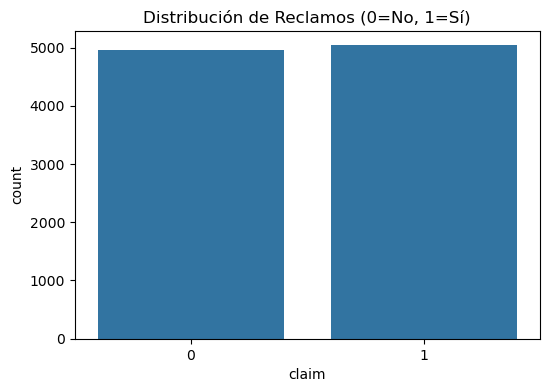

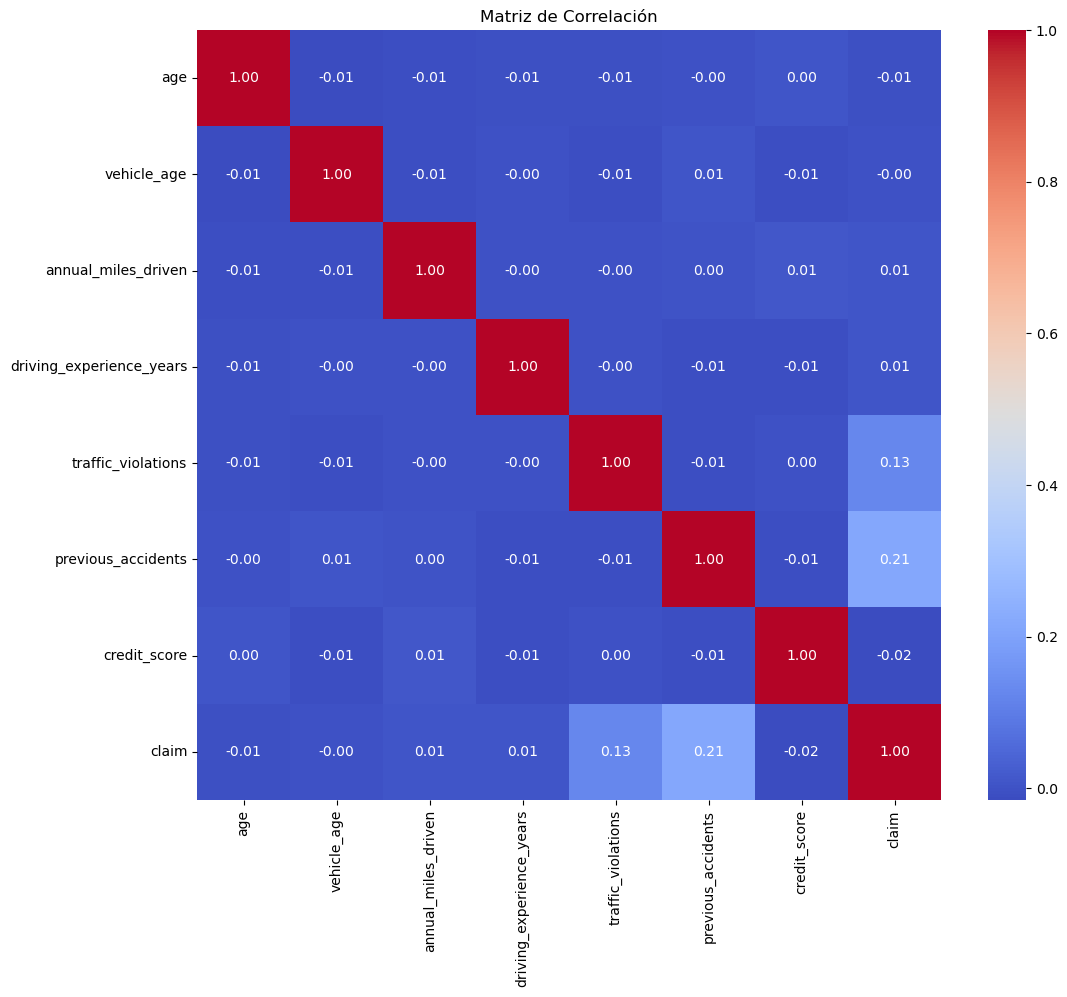

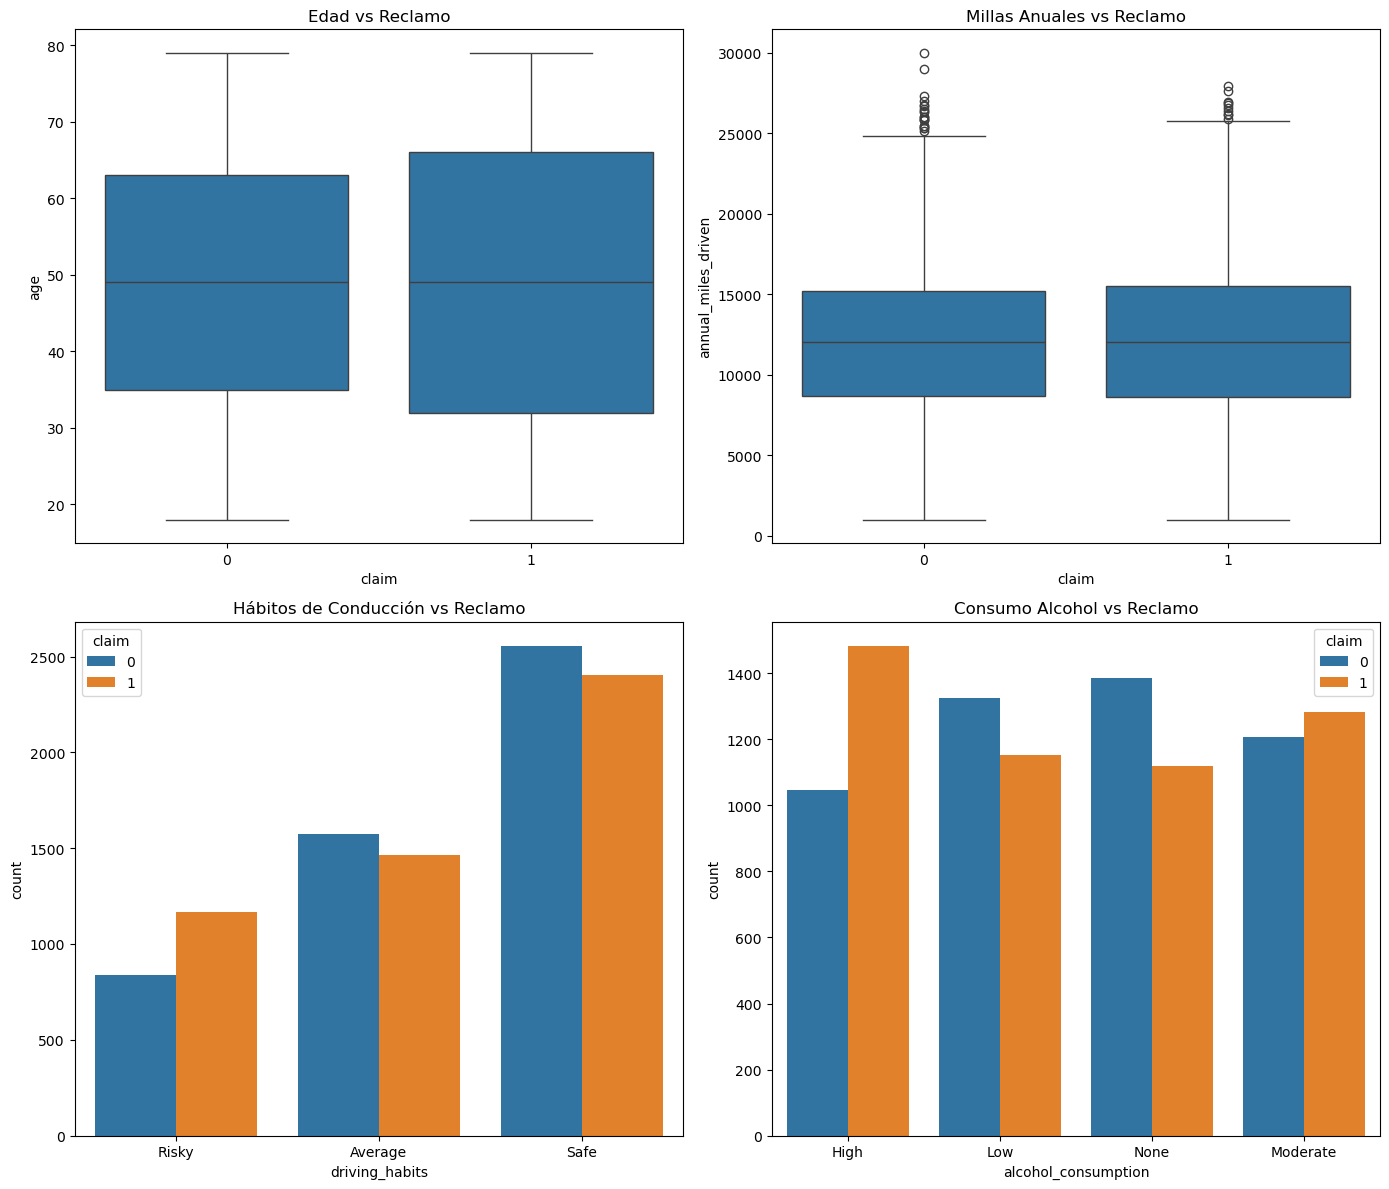


=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===
      actual  probability risk_level
1784       0     0.409049      Medio
3840       1     0.446156      Medio
6102       0     0.498111      Medio
56         1     0.363152      Medio
949        0     0.348676      Medio
5261       1     0.357603      Medio
1068       0     0.712547       Alto
1703       1     0.605949      Medio
3429       0     0.470300      Medio
5466       0     0.590463      Medio

Distribución de niveles de riesgo en test:
risk_level
Medio    84.45
Bajo      8.70
Alto      6.85
Name: proportion, dtype: float64

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       992
           1       0.64      0.64      0.64      1008

    accuracy                           0.64      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.64      0.64      0.64      2000

AUC-ROC: 0.6836
Average Precision: 0.

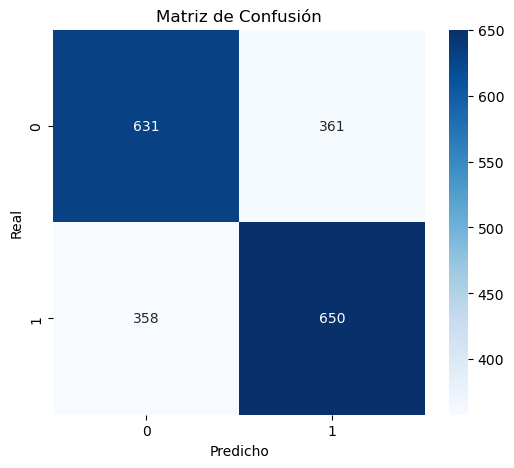

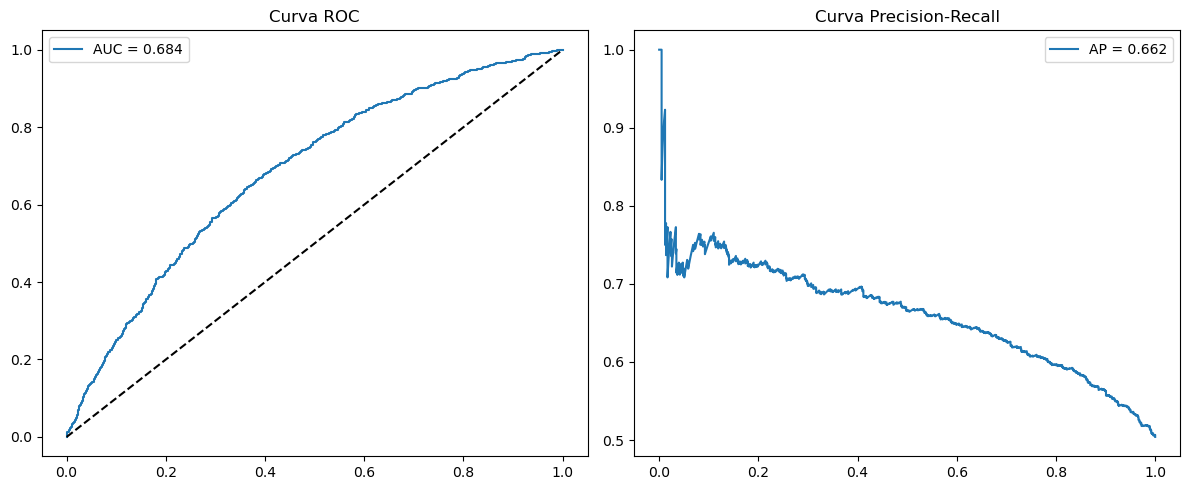

100%|██████████| 50/50 [00:03<00:00, 15.41it/s]


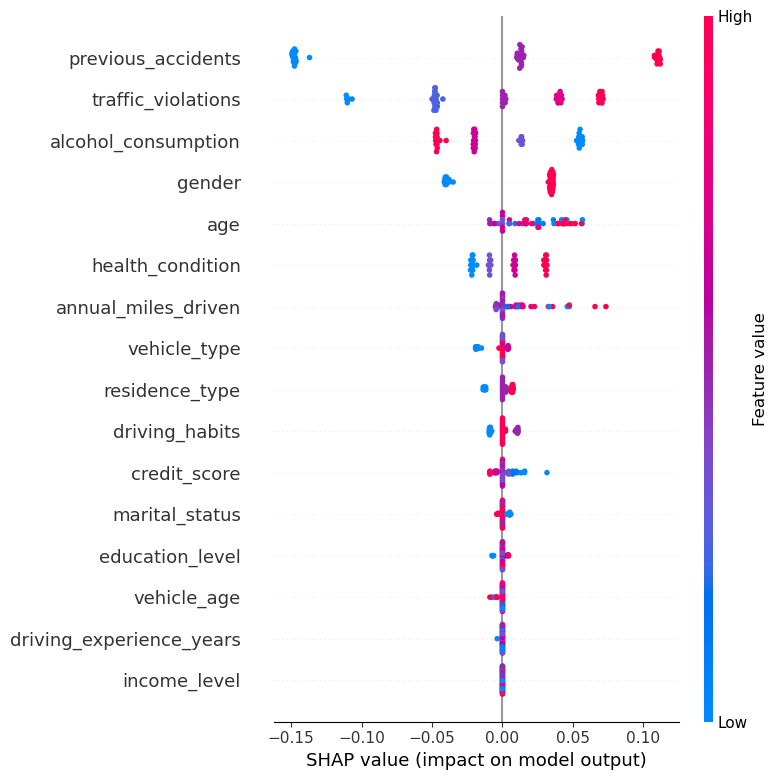

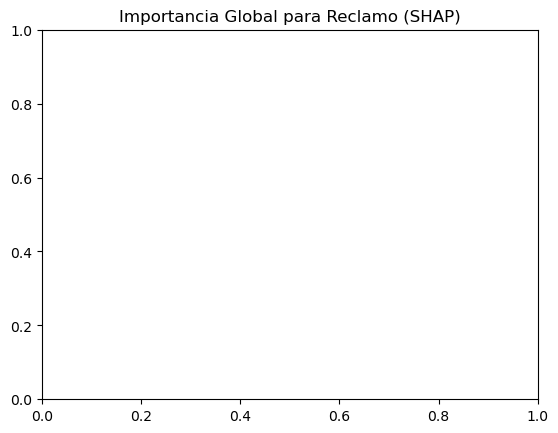

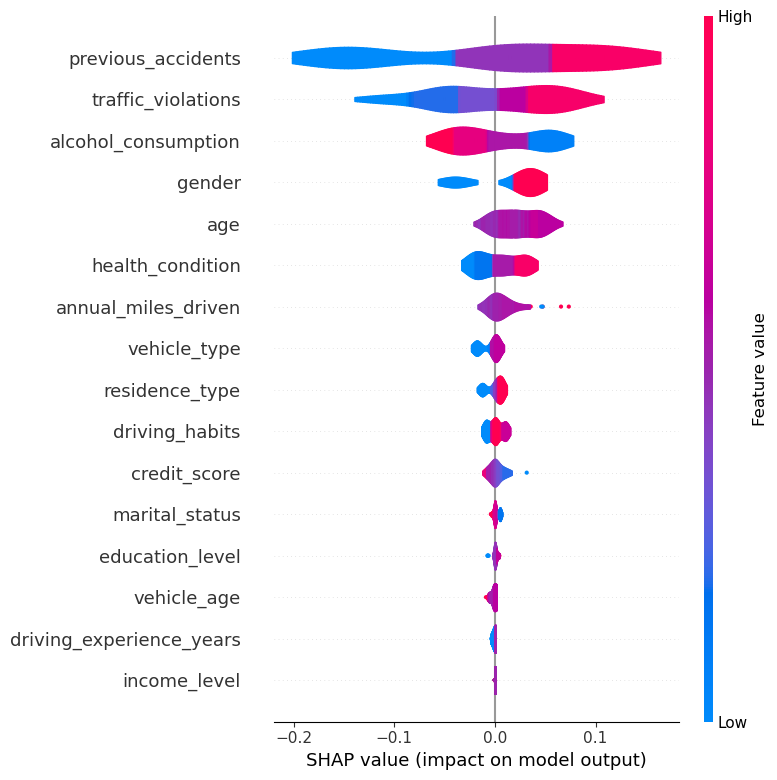

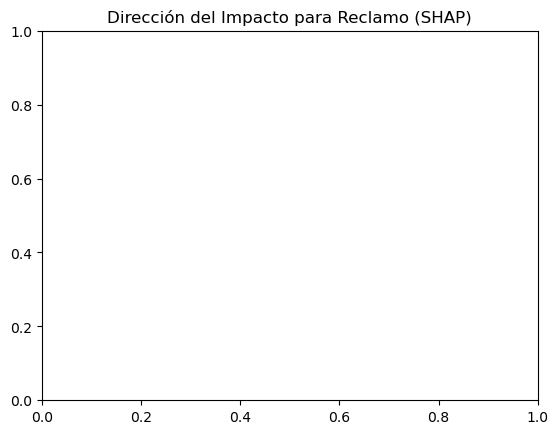


Ejemplo individual (alto riesgo): Probabilidad 71.25%


IndexError: index 1068 is out of bounds for axis 0 with size 50

In [4]:
# =======================================================
# Ejemplo completo: Predicción de Probabilidad de Reclamo en Seguros de Auto con Naive Bayes
# Problema de CLASIFICACIÓN BINARIA: predecir 'claim' (1 = reclamo, 0 = no reclamo)
# Dataset sintético profesional con 16 variables realistas para seguros de auto
# Incluye: EDA, entrenamiento, métricas, predicciones, análisis de riesgo (bajo/medio/alto con probabilidades),
# y análisis de sensibilidad con SHAP (KernelExplainer para Naive Bayes)
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn matplotlib seaborn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB  # Naive Bayes para variables mixtas (asumimos Gaussian)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
import shap
from shap import KernelExplainer
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos 10,000 conductores con 16 variables realistas para seguros de auto
# Target: 'claim' (1 = reclamo en el año, 0 = no) generado con lógica probabilística
np.random.seed(42)
n_samples = 10000

data = {
    # Demográficas
    'age': np.random.randint(18, 80, n_samples),  # Edad del conductor
    'gender': np.random.choice(['Male', 'Female'], n_samples, p=[0.55, 0.45]),  # Género
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced'], n_samples),  # Estado civil
    'education_level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),  # Nivel educativo
    'income_level': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.3, 0.5, 0.2]),  # Nivel ingresos
    'residence_type': np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples),  # Tipo de residencia
    
    # Vehículo y conducción
    'vehicle_age': np.random.randint(0, 20, n_samples),  # Edad del vehículo
    'vehicle_type': np.random.choice(['Sedan', 'SUV', 'Truck', 'Sports Car'], n_samples),  # Tipo de vehículo
    'annual_miles_driven': np.random.normal(12000, 5000, n_samples).clip(1000, 30000).astype(int),  # Millas anuales
    'driving_experience_years': np.random.randint(0, 60, n_samples),  # Años de experiencia
    'traffic_violations': np.random.randint(0, 5, n_samples),  # Violaciones de tráfico en los últimos 5 años
    'previous_accidents': np.random.randint(0, 3, n_samples),  # Accidentes previos
    
    # Médicas/Comportamiento
    'alcohol_consumption': np.random.choice(['None', 'Low', 'Moderate', 'High'], n_samples),  # Consumo alcohol
    'health_condition': np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], n_samples),  # Condición de salud
    'credit_score': np.random.normal(700, 100, n_samples).clip(300, 850).astype(int),  # Puntaje crediticio
    'driving_habits': np.random.choice(['Safe', 'Average', 'Risky'], n_samples, p=[0.5, 0.3, 0.2])  # Hábitos de conducción
}

df = pd.DataFrame(data)

# Generar 'claim' con lógica probabilística realista (mayor riesgo = mayor prob reclamo)
claim_prob = (
    0.05 +  # Base 5%
    0.20 * (df['age'] < 25) + 0.10 * (df['age'] > 65) +  # Jóvenes y mayores
    0.08 * (df['gender'] == 'Male') +  # Hombres ligeramente más riesgo
    0.15 * (df['traffic_violations'] > 1) +  # Violaciones
    0.25 * (df['previous_accidents'] > 0) +  # Accidentes previos
    0.12 * (df['alcohol_consumption'] == 'High') + 0.06 * (df['alcohol_consumption'] == 'Moderate') +  # Alcohol
    0.10 * (df['driving_habits'] == 'Risky') +  # Hábitos riesgosos
    0.08 * (df['health_condition'] == 'Poor') + 0.04 * (df['health_condition'] == 'Fair') +  # Salud pobre
    0.07 * (df['annual_miles_driven'] > 20000) +  # Muchas millas
    0.05 * (df['vehicle_type'] == 'Sports Car')  # Tipo vehículo riesgoso
)
claim_prob = claim_prob.clip(0, 0.95)
df['claim'] = np.random.binomial(1, claim_prob)

print(f"Dataset creado: {df.shape[0]} filas, {df.shape[1]} columnas (16 features + target)")
print(f"Porcentaje de reclamos: {df['claim'].mean()*100:.2f}%")

# =======================================================
# 3. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== Descripción estadística general ===")
print(df.describe(include='all'))

# Distribución de reclamos
plt.figure(figsize=(6,4))
sns.countplot(x='claim', data=df)
plt.title('Distribución de Reclamos (0=No, 1=Sí)')
plt.show()

# Correlación numérica
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Variables clave vs reclamo
fig, axes = plt.subplots(2, 2, figsize=(14,12))
sns.boxplot(x='claim', y='age', data=df, ax=axes[0,0])
axes[0,0].set_title('Edad vs Reclamo')
sns.boxplot(x='claim', y='annual_miles_driven', data=df, ax=axes[0,1])
axes[0,1].set_title('Millas Anuales vs Reclamo')
sns.countplot(x='driving_habits', hue='claim', data=df, ax=axes[1,0])
axes[1,0].set_title('Hábitos de Conducción vs Reclamo')
sns.countplot(x='alcohol_consumption', hue='claim', data=df, ax=axes[1,1])
axes[1,1].set_title('Consumo Alcohol vs Reclamo')
plt.tight_layout()
plt.show()

# =======================================================
# 4. Preprocesamiento
# =======================================================
# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Separar features y target
X = df.drop('claim', axis=1)
y = df['claim']

# Escalar variables numéricas (Naive Bayes Gaussian beneficia de escalado)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (estratificado por desbalanceo)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# =======================================================
# 5. Entrenamiento del modelo GaussianNB (Naive Bayes)
# =======================================================
model = GaussianNB()
model.fit(X_train, y_train)

# =======================================================
# 6. Predicciones y probabilidades
# =======================================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidad de claim=1

# =======================================================
# 7. Clasificación de riesgo basada en probabilidad
# =======================================================
def classify_risk(prob):
    if prob < 0.3:
        return 'Bajo'
    elif prob < 0.7:
        return 'Medio'
    else:
        return 'Alto'

df_test = pd.DataFrame({'actual': y_test, 'probability': y_prob})
df_test['predicted_class'] = y_pred
df_test['risk_level'] = df_test['probability'].apply(classify_risk)

print("\n=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===")
print(df_test[['actual', 'probability', 'risk_level']].head(10))

print("\nDistribución de niveles de riesgo en test:")
print(df_test['risk_level'].value_counts(normalize=True) * 100)

# =======================================================
# 8. Métricas de evaluación completas (clasificación)
# =======================================================
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Curvas ROC y Precision-Recall
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('Curva ROC')
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f'AP = {average_precision_score(y_test, y_prob):.3f}')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

# =======================================================
# 9. Análisis de sensibilidad con SHAP (KernelExplainer para Naive Bayes)
# =======================================================
# Fondo resumido con kmeans para velocidad
background = shap.kmeans(X_train, 100).data

# Definir función para predecir probabilidad de clase 1 (para single output SHAP)
def model_predict(data):
    return model.predict_proba(data)[:, 1]

explainer = KernelExplainer(model_predict, background)

# SHAP values en subconjunto de test (50 muestras para demo)
shap_test_subset = X_test[:50]
shap_values = explainer.shap_values(shap_test_subset)

# Importancia global (para reclamo)
shap.summary_plot(shap_values, shap_test_subset, feature_names=X.columns)
plt.title('Importancia Global para Reclamo (SHAP)')
plt.show()

# Dirección del impacto
shap.summary_plot(shap_values, shap_test_subset, plot_type="violin", feature_names=X.columns)
plt.title('Dirección del Impacto para Reclamo (SHAP)')
plt.show()

# Ejemplo individual (primer caso de alto riesgo predicho)
high_risk_idx = df_test[df_test['risk_level'] == 'Alto'].index[0]
local_idx = np.where(X_test.index == high_risk_idx)[0][0] if hasattr(X_test, 'index') else high_risk_idx  # Ajuste para np.array
print(f"\nEjemplo individual (alto riesgo): Probabilidad {df_test.loc[high_risk_idx, 'probability']:.2%}")
shap.force_plot(explainer.expected_value, shap_values[local_idx], 
                shap_test_subset[local_idx], feature_names=X.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("Variables más influyentes: traffic_violations, previous_accidents, age, driving_habits, alcohol_consumption, etc.")
print("Naive Bayes es eficiente para clasificación con variables independientes en datos de seguros.")
print("SHAP con KernelExplainer proporciona sensibilidad, aunque es computacionalmente intensivo; usa subconjuntos para pruebas.")